**Objetivo:** Implementar un detector de máximo enfoque sobre un video aplicando técnicas de análisis espectral similar al que utilizan las cámaras digitales modernas. El video a procesar será: “focus_video.mov”.
1. Se debe implementar un algoritmo que dada una imagen, o región, calcule la métrica propuesta en el paper "Image Sharpness Measure for Blurred Images in Frequency Domain“ y realizar tres experimentos:
    1. Medición sobre todo el frame.
    2. Medición sobre una ROI ubicada en el centro del frame. Area de la ROI = 5 o 10% del area total del frame.
    - Opcional:
        - Medición sobre una matriz de enfoque compuesta por un arreglo de NxM elementos rectangulares equiespaciados. N y M son valores arbitrarios, probar con varios valores 3x3, 7x5, etc ... (al menos 3)
    - Para cada experimento se debe presentar :
        - Una curva o varias curvas que muestren la evolución de la métrica frame a frame donde se vea claramente cuando el algoritmo detecto el punto de máximo enfoque.  

2. Cambiar la métrica de enfoque eligiendo uno de los algoritmos explicados en el apéndice de: Analysis of focus measure operators in shapefrom focus.

El algoritmo de detección a implementar debe detectar y devolver los puntos de máximo enfoque de manera
automática.

In [14]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt
from functools import partial

Del paper *Image Sharpness Measure for Blurred Images in Frequency Domain* tenemos que el algorítmo propuesto para determinar el nivel de foco tiene los siguientes pasos:
1. Computar la transformada de Fourier de la imagen: $I\Longrightarrow F$
```python
image_fourier = np.fft.fft2(image)
```
2. Encontrar $F_c$ moviendo el origen de $F$ al centro.
```python
image_fourier = np.fft.fftshift(image_fourier)
```
3. Calcular $AF=abs(F_c)$, es decir el valor absoluto elemento a elemento de $F_c$.
```python
af = np.abs(image_fourier)
```
4. Calcular el máximo valor $M$ del componente de frecuencia de $AF$.
```python
max_af = np.max(af)
```
5. Contar la cantidad de pixeles $T_H$ que tienen valor $>thres=\frac{M}{1000}$.
```python
thres = max_af / 1000
th = 0
for row in af:
    for pixel in row:
        if pixel > thres:
            th += 1
```
6. Calcular la métrica como $$\text{Image Quality Measure}=\frac{T_H}{m\cdot n}$$ siendo $m$ y $n$ el tamaño de la imagen en pixeles.
```python
m, n = image.shape
iqm = th / (m * n)
```

A continuación se tiene el algoritmo implementado en una función:

In [2]:
def kanjar_algorithm(image):
    m, n = image.shape
    # Genero la transformacion de Fourier de la imagen
    image_fourier = np.fft.fft2(image)
    # Shifteo el origen de la TF al centro
    image_fourier = np.fft.fftshift(image_fourier)
    # Computo el valor absoluto de la TF centrada
    af = np.abs(image_fourier)
    # Calculo el maximo de AF
    max_af = np.max(af)
    # Calculo la cantidad de pixeles con valor > thres
    thres = max_af / 1000
    th = 0
    for row in af:
        for pixel in row:
            if pixel > thres:
                th += 1
    # Computo la metrica
    iqm = th / (m * n)
    return iqm

Defino una función que permita computar la métrica (u otra métrica que tenga por input sólo el frame y como output el valor de la métrica) a partir de un video, y además que me permita computar la métrica para el centro del frame (definiendo un cierto porcentaje para tomar del centro) o para una matriz de enfoque (dando el tamaño de cada zona y la cantidad de zonas totales en cada dirección, siempre centradas en la imagen). Esta función nos devuelve una lista con el valor de la métrica en cada frame del video.

In [3]:
def compute_focus_metric_for_video(
        video_path,
        focus_metric_fun=kanjar_algorithm,
        center_frame = False,
        focus_matrix = False,
        center_percentage = None,
        focus_matrix_zone_size = (None, None),
        focus_matrix_zones = (None, None),
        ):

    # Check de que tenga los datos necesarios según la zona de calculo
    if center_frame and focus_matrix:
        return ValueError("center_frame y focus_matrix no pueden ambos ser True, sólo 1 puede serlo.")
    if center_frame:
        if not bool(center_percentage):
            return ValueError("falta especificar center_percentage para el cómputo de la métrica en el centro del frame.")
    if focus_matrix:
        if (
            not bool(focus_matrix_zone_size[0]) or not bool(focus_matrix_zone_size[1]) or
            not bool(focus_matrix_zones[0]) or not bool(focus_matrix_zones[1])
        ):
            return ValueError("falta especificar alguna de las tuplas para cómputo por matriz de enfoque. A saber: focus_matrix_zone_size (tamaño de las zonas de enfoque en cada dirección) y focus_matrix_zones (cantidad de zonas de enfoque en cada dirección)")
    
    captura_video = cv.VideoCapture(video_path)

    metric = []
    if not captura_video.isOpened():
        raise Exception("Error al abrir el archivo de video")
    else:
        i = 0
        while True:
            ret, frame = captura_video.read()
            if not ret:
                break
            frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)

            # Modificacion del frame segun la zona/zonas de enfoque definidas
            m,n = frame.shape
            if center_frame:
                ymin, ymax = int(m/2 - center_percentage/2 * m), int(m/2 + center_percentage/2 * m)
                xmin, xmax = int(n/2 - center_percentage/2 * n), int(n/2 + center_percentage/2 * n)
                frame = frame[ymin:ymax, xmin:xmax]
            elif focus_matrix:
                center_x, center_y = int(m/2), int(n/2)
                rows = [
                    (int((center_x + 2*(i - focus_matrix_zones[0])*focus_matrix_zone_size[0]) - (focus_matrix_zone_size[0] - 1)/2), 
                    int((center_x + 2*(i - focus_matrix_zones[0])*focus_matrix_zone_size[0]) + (focus_matrix_zone_size[0] - 1)/2))
                    for i in range(focus_matrix_zones[0]*2 + 1)
                ]
                cols = [
                    (int((center_y + 2*(i - focus_matrix_zones[1])*focus_matrix_zone_size[1]) - (focus_matrix_zone_size[1] - 1)/2), 
                    int((center_y + 2*(i - focus_matrix_zones[1])*focus_matrix_zone_size[1]) + (focus_matrix_zone_size[1] - 1)/2))
                    for i in range(focus_matrix_zones[1]*2 + 1)
                ]
                frame = np.concatenate([frame[r1:r2, c1:c2] for r1,r2 in rows for c1,c2 in cols])
            # Si full_frame, no se modifica frame

            metric.append(focus_metric_fun(frame))

    return metric

Defino la función `get_focus_frames` que nos entrega una lista de tuplas que nos dicen según un threshold del valor de la métrica si el frame está o no enfocado, dando el mínimo y máximo de periodos de enfoque.

In [5]:
def get_focus_frames(metric_list, thres, norm=True):
    focus_zones = []
    focused = False
    thres = thres if not norm else thres * np.max(metric_list)
    for frame, point in enumerate(metric_list):
        if point > thres and not focused:
            focused = True
            focus_zones.append(frame)
        if focused and point < thres:
            focused = False
            focus_zones[-1] = (focus_zones[-1],frame)

    return focus_zones

# focus_zones_full = get_focus_frames(metric, 0.8, norm=False)
# focus_zones_full_norm = get_focus_frames(metric, 0.8, norm=True)

# focus_zones_center = get_focus_frames(metric_center, 0.8, norm=False)
# focus_zones_center_norm = get_focus_frames(metric_center, 0.8, norm=True)

# focus_zones_matrix = get_focus_frames(metric_matriz_enfoque, 0.8, norm=False)
# focus_zones_matrix_norm = get_focus_frames(metric_matriz_enfoque, 0.8, norm=True)

Defino otra función que permite visualizar el video, y además poner debajo del mismo el texto si según una métrica está enfocado 

In [6]:
def view_video(captura_video, focus_zones):
    '''
    '''
    # Va al frame 0
    captura_video.set(cv.CAP_PROP_POS_FRAMES, 0)
    if not captura_video.isOpened():
        print("Error al abrir el archivo de video")
    else:
        # Obtén la tasa de cuadros (frame rate) del video
        fps = int(captura_video.get(cv.CAP_PROP_FPS)) * 0.25
        #fps = 35
        delay = int(600 / fps)
        
        banner_height = 40 + 30 * (len(focus_zones.keys()) - 1) # How tall you want the banner to be

        frame_count = 0
        while True:
            ret, frame = captura_video.read()
            frame_count += 1
            if not ret:
                break

            h, w, channels = frame.shape
            composite_frame = np.zeros((h+banner_height, w, channels), dtype=np.uint8)
            composite_frame[0:h, 0:w] = frame

            percent = 0.05
            percent = 0.10
            cv.rectangle(composite_frame, (int(w/2 - w*percent/2), int(h/2 - h*percent/2)), (int(w/2 + w*percent/2), int(h/2 + h*percent/2)), (0, 255, 0), 3)
            
            metric_counter = 0
            for metric in focus_zones.keys():
                in_focus = False
                for focus_zone in focus_zones[metric]:
                    if frame_count >= focus_zone[0] and frame_count <= focus_zone[1]:
                        in_focus = True
                banner_text = f"{metric}: Enfocado" if in_focus else f"{metric}: No enfocado"

                text_position = (20, h + 30 * (1 + metric_counter)) # X, Y coordinates for the text start
                metric_counter += 1
                cv.putText(composite_frame, banner_text, text_position, cv.FONT_HERSHEY_SIMPLEX, 
                            0.8, (255, 255, 255), 2, cv.LINE_AA)
            
            # Mostrar el frame combinado
            cv.imshow('Video Original y Blur Gaussiano', composite_frame)
            
            # Salir del loop si se presiona la tecla 'q'
            if cv.waitKey(delay) & 0xFF == ord('q'):
                break

    # Cierra todas las ventanas
    cv.destroyAllWindows()

NameError: name 'modified_laplacian_algorithm' is not defined

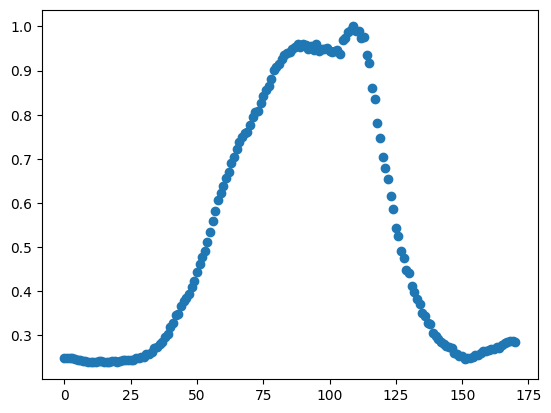

In [7]:
metric = compute_focus_metric_for_video('focus_video.mov')
plt.scatter(range(len(metric)), metric/np.max(metric))

metric_LAP2 = compute_focus_metric_for_video('focus_video.mov', focus_metric_fun=modified_laplacian_algorithm)
# print(metric_LAP2)
plt.scatter(range(len(metric_LAP2)), metric_LAP2/np.max(metric_LAP2))

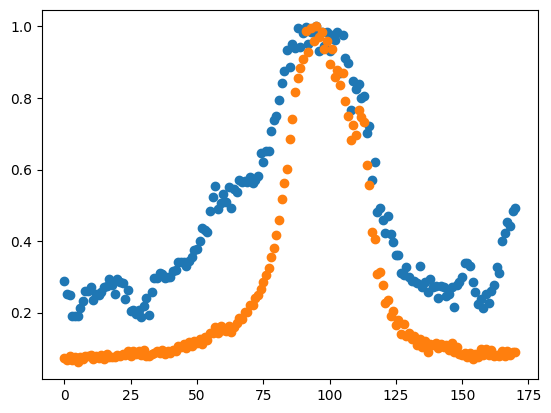

In [20]:
# Aplico las mismas metricas pero al centro (5% central) del frame
metric = compute_focus_metric_for_video('focus_video.mov', center_frame=True, center_percentage=0.05)
plt.scatter(range(len(metric)), metric/np.max(metric))

metric_LAP2 = compute_focus_metric_for_video('focus_video.mov', focus_metric_fun=modified_laplacian_algorithm, center_frame=True, center_percentage=0.05)
# print(metric_LAP2)
plt.scatter(range(len(metric_LAP2)), metric_LAP2/np.max(metric_LAP2))


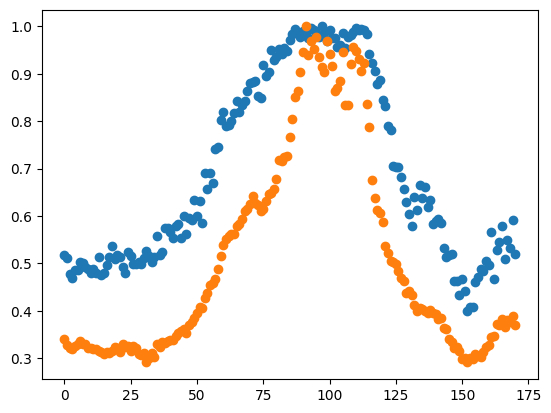

In [21]:
# Aplico las mismas metricas pero al centro (5% central) del frame
metric = compute_focus_metric_for_video('focus_video.mov',
                                        focus_matrix=True,
                                        focus_matrix_zone_size=(3,3),
                                        focus_matrix_zones=(5,5)
                                        )
plt.scatter(range(len(metric)), metric/np.max(metric))

metric_LAP2 = compute_focus_metric_for_video('focus_video.mov',
                                             focus_metric_fun=modified_laplacian_algorithm,
                                             focus_matrix=True, 
                                             focus_matrix_zone_size=(3,3), 
                                             focus_matrix_zones=(5,5)
                                             )
# print(metric_LAP2)
plt.scatter(range(len(metric_LAP2)), metric_LAP2/np.max(metric_LAP2))

In [86]:
video_path = 'focus_video.mov'
captura_video = cv.VideoCapture(video_path)

metric = []
metric_center = []
metric_matriz_enfoque = []
if not captura_video.isOpened():
    raise Exception("Error al abrir el archivo de video")
else:
    i = 0
    while True:
        ret, frame = captura_video.read()
        if not ret:
            break
        frame = cv.cvtColor(frame, cv.COLOR_BGR2GRAY)
        metric.append(kanjar_algorithm(frame))

        # Metrica con centro de la imagen
        m, n = frame.shape
        percent = 0.05
        ymin, ymax = int(m/2 - percent/2 * m), int(m/2 + percent/2 * m)
        xmin, xmax = int(n/2 - percent/2 * n), int(n/2 + percent/2 * n)
        frame_center = frame[ymin:ymax, xmin:xmax]
        metric_center.append(kanjar_algorithm(frame_center))

        # Metrica con matriz de enfoque
        center_x, center_y = int(m/2), int(n/2)
        focus_m, focus_n = (5,3) # tamaño de las zonas de enfoque
        m_matrix, n_matrix = (7,5) # cantidad de zonas de enfoque
        rows = [
            (int((center_x + 2*(i - m_matrix)*focus_m) - (focus_m - 1)/2), 
             int((center_x + 2*(i - m_matrix)*focus_m) + (focus_m - 1)/2))
            for i in range(m_matrix*2 + 1)
        ]
        cols = [
            (int((center_y + 2*(i - n_matrix)*focus_n) - (focus_n - 1)/2), 
             int((center_y + 2*(i - n_matrix)*focus_n) + (focus_n - 1)/2))
            for i in range(n_matrix*2 + 1)
        ]
        focus_matrix = np.concatenate([frame[r1:r2,c1:c2] for r1,r2 in rows for c1,c2 in cols])
        metric_matriz_enfoque.append(kanjar_algorithm(focus_matrix))


In [1]:
view_video(captura_video, {1: [(0,50), (100,150)], 2: [(30,70)]})

NameError: name 'view_video' is not defined

In [92]:
view_video(
    captura_video=captura_video,
    focus_zones={
        "Full frame normalizado": focus_zones_full_norm,
        "Centro de  frame normalizado": focus_zones_center_norm,
        "Matriz de enfoque": focus_zones_matrix,
    }
)

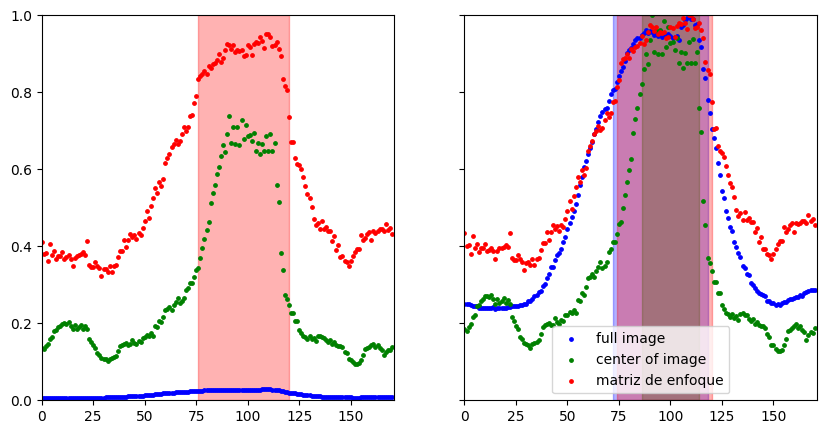

In [72]:
fig, axs = plt.subplots(1,2,figsize=(10,5), sharex=True, sharey=True)

axs[0].scatter(range(len(metric)), metric, label='full image', color='blue', s=6,zorder=2)
axs[0].scatter(range(len(metric_center)), metric_center, label='center of image', color='green', s=6,zorder=2)
axs[0].scatter(range(len(metric_matriz_enfoque)), metric_matriz_enfoque, label='matriz de enfoque', color='red', s=6,zorder=2)
# axs[0].fill_between(focus_zones_full[0],1,alpha=0.3,color='blue',zorder=1)
# axs[0].fill_between(focus_zones_center[0],1,alpha=0.3,color='green',zorder=1)
axs[0].fill_between(focus_zones_matrix[0],1,alpha=0.3,color='red',zorder=1)

axs[1].scatter(range(len(metric)), metric/np.max(metric), label='full image', color='blue', s=6,zorder=2)
axs[1].scatter(range(len(metric_center)), metric_center/np.max(metric_center), label='center of image', color='green', s=6,zorder=2)
axs[1].scatter(range(len(metric_matriz_enfoque)), metric_matriz_enfoque/np.max(metric_matriz_enfoque), label='matriz de enfoque', color='red', s=6,zorder=2)
axs[1].fill_between(focus_zones_full_norm[0],1,alpha=0.3,color='blue',zorder=1)
axs[1].fill_between(focus_zones_center_norm[0],1,alpha=0.3,color='green',zorder=1)
axs[1].fill_between(focus_zones_matrix_norm[0],1,alpha=0.3,color='red',zorder=1)
axs[1].legend()

for ax in axs:
    [ax.fill_between(focus_zone,1,alpha=0.3,color='blue',zorder=1) for focus_zone in focus_zones_full]
    [ax.fill_between(focus_zone,1,alpha=0.3,color='blue',zorder=1) for focus_zone in focus_zones_full]
    ax.set_ylim(0,1)
    ax.set_xlim(0,len(metric))

Como métrica adicional decidí utilizar la denominada *LAP2* o *Modified Laplacian* propuesta por *Nayar*, ya que fue el algorítmo que mejor performance tuvo en las imagenes de los 3 origenes planteados en el paper. La misma se computa de la siguiente forma, considerando que se aplica a las posiciones $(i,j)$ para la posición $(x,y)$:
$$
\phi_{x,y} = \sum_{(i,j)\in\Omega(x,y)} \Delta_m I(i,j)
$$
siendo
$$
\Delta_m I(i,j) = \left| I \ast L_x\right| +  \left| I \ast L_y\right|
$$
y 
$$
L_x = \left[-1; 2; -1\right] \quad L_y=L_x^T
$$
Para el caso de este TP, queremos una métrica para todo el frame, una zona central o la combinación de varias zonas (matriz de enfoque). Entonces hacemos que $(i,j)$ contenga a toda la zona de interés, y obtenemos un único $\phi$.

Adicionalmente, para compararlo, debemos nuevamente normalizar, ya que los valores de esta métrica no están en el mismo orden de magnitud que las métricas previamente utilizadas.

A continuación se tiene la función que computa la métrica dado un frame:

In [9]:
from scipy.signal import convolve2d
def modified_laplacian_algorithm(frame):
    # Mascaras de convolución
    L_x = np.array([[-1, 2, -1]])
    L_y = L_x.T

    # Aplico la convolució\left| I \ast L_x\right|n
    ILx = convolve2d(frame, L_x, mode='same', boundary='symm')
    ILy = convolve2d(frame, L_y, mode='same', boundary='symm')

    # Computo la métrica
    delta_m_I = np.abs(ILx) + np.abs(ILy)
    metric = np.sum(delta_m_I)

    return metric

[np.int64(253536), np.int64(247688), np.int64(267418), np.int64(263234), np.int64(287458), np.int64(278962), np.int64(291050), np.int64(279214), np.int64(301222), np.int64(295182), np.int64(310206), np.int64(293342), np.int64(314438), np.int64(298254), np.int64(315952), np.int64(299146), np.int64(318812), np.int64(304648), np.int64(320684), np.int64(306994), np.int64(319882), np.int64(310266), np.int64(321516), np.int64(303526), np.int64(323732), np.int64(306484), np.int64(327894), np.int64(309288), np.int64(329778), np.int64(313592), np.int64(333600), np.int64(326038), np.int64(303058), np.int64(319778), np.int64(316218), np.int64(330008), np.int64(324112), np.int64(340102), np.int64(337450), np.int64(352692), np.int64(343646), np.int64(361764), np.int64(353698), np.int64(374782), np.int64(361618), np.int64(388238), np.int64(374158), np.int64(401508), np.int64(382106), np.int64(419902), np.int64(412402), np.int64(448412), np.int64(455460), np.int64(512052), np.int64(475834), np.int64(

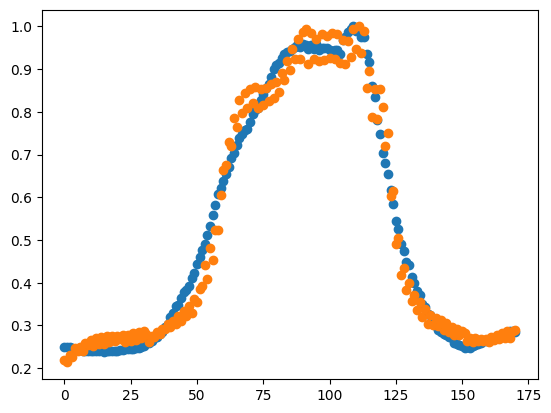

In [20]:
metric = compute_focus_metric_for_video('focus_video.mov')
plt.scatter(range(len(metric)), metric/np.max(metric))

metric_LAP2 = compute_focus_metric_for_video('focus_video.mov', focus_metric_fun=modified_laplacian_algorithm)
print(metric_LAP2)
plt.scatter(range(len(metric_LAP2)), metric_LAP2/np.max(metric_LAP2))

# Aplicación de unsharp masking

In [21]:
def unsharp_mask(frame, metric_function=kanjar_algorithm):
    frame_gaussian = cv.GaussianBlur(frame, (0,0), 2.0)
    frame_high_freq = frame - frame_gaussian
    frame_sharp = frame + frame_high_freq
    return metric_function(frame_sharp)

[0.007513020833333333, 0.0075217013888888885, 0.007469618055555556, 0.007486979166666667, 0.007469618055555556, 0.0074435763888888885, 0.007478298611111111, 0.007365451388888889, 0.0073741319444444444, 0.007287326388888889, 0.007365451388888889, 0.007296006944444444, 0.0073046875, 0.0071571180555555555, 0.0071571180555555555, 0.007261284722222222, 0.007261284722222222, 0.0072352430555555555, 0.007139756944444444, 0.0071657986111111115, 0.0072265625, 0.007287326388888889, 0.007417534722222222, 0.007322048611111111, 0.007408854166666667, 0.0073741319444444444, 0.007365451388888889, 0.007556423611111111, 0.007651909722222222, 0.0077473958333333336, 0.007764756944444445, 0.007947048611111111, 0.007981770833333334, 0.008059895833333334, 0.0082421875, 0.008433159722222222, 0.008754340277777778, 0.009014756944444445, 0.009518229166666666, 0.009587673611111111, 0.010186631944444444, 0.01041232638888889, 0.010985243055555555, 0.011202256944444445, 0.011627604166666666, 0.012330729166666667, 0.0

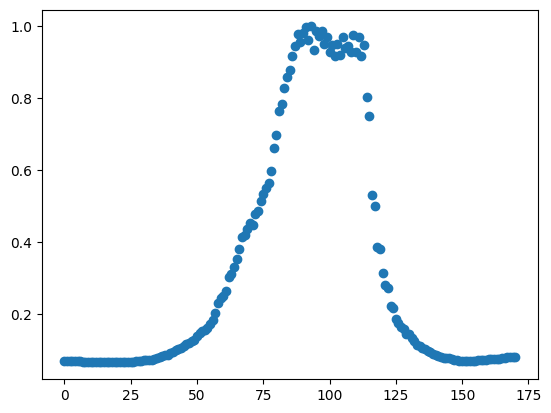

In [ ]:
# unsharp_mask_kanjar = partial(partial, unsharp_mask, metric_function=kanjar_algorithm)
# metric_unsharp_mask = compute_focus_metric_for_video('focus_video.mov', focus_metric_fun=unsharp_mask_kanjar)
metric_unsharp_mask = compute_focus_metric_for_video('focus_video.mov', focus_metric_fun=unsharp_mask)
# print(metric_unsharp_mask)

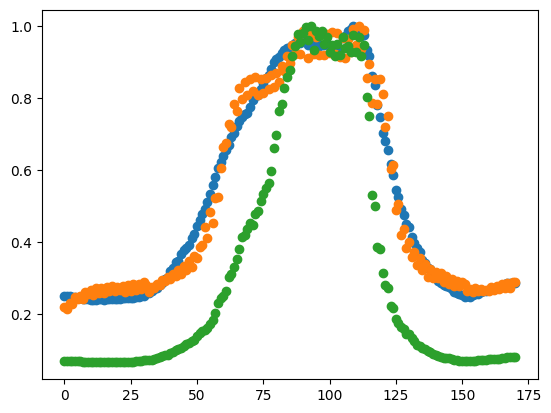

In [ ]:
plt.scatter(range(len(metric)), metric/np.max(metric))
plt.scatter(range(len(metric_LAP2)), metric_LAP2/np.max(metric_LAP2))
plt.scatter(range(len(metric_unsharp_mask)), metric_unsharp_mask/np.max(metric_unsharp_mask))
